<a href="https://colab.research.google.com/github/channel1umut-lang/Python-for-Data-Science/blob/main/0016_BalancingData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#random seed
np.random.seed(101) # tutarli bir rastgelelik elde edebilmek icin kullaniyoruz.

set1no = 900
set2no = 100


In [ ]:
df1 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale = 1, size=set1no),
    "feature_2": np.random.normal(loc=0, scale = 1, size=set1no),
    "target": [0]*set1no
})
df2 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale = 1, size=set2no),
    "feature_2": np.random.normal(loc=0, scale = 1, size=set2no),
    "target": [1]*set2no
})

In [ ]:
df1.head(10)

,feature_1,feature_2,target
0,2.706850,0.536932,0
1,0.628133,-1.470013,0
2,0.907969,0.701910,0
3,0.503826,1.550226,0
4,0.651118,2.155953,0
5,-0.319318,0.177432,0
6,-0.848077,0.296588,0
7,0.605965,-0.100191,0
8,-2.018168,1.703387,0
9,0.740122,0.530008,0


In [ ]:
df2.head(10)

,feature_1,feature_2,target
0,-0.929423,-0.377268,1
1,-0.149955,-2.139719,1
2,3.240698,-0.601153,1
3,0.352624,-1.206681,1
4,-0.025048,0.034775,1
5,-0.635098,1.009433,1
6,-0.248557,-0.092056,1
7,-0.148381,-1.548252,1
8,1.417372,-0.466474,1
9,1.312746,0.194632,1


In [ ]:
df = pd.concat([df1,df2]).reset_index(drop=True) #Eğer drop=True yazmazsan eski index ayrıca bir sütun olarak eklenir.

In [ ]:
df

,feature_1,feature_2,target
0,2.706850,0.536932,0
1,0.628133,-1.470013,0
2,0.907969,0.701910,0
3,0.503826,1.550226,0
4,0.651118,2.155953,0
...,...,...,...
995,-1.630421,0.793099,1
996,-1.269207,4.260621,1
997,1.489793,0.043938,1
998,0.068373,1.287646,1


In [ ]:
df["target"].unique()

array([0, 1])

In [ ]:
df["target"].value_counts()

,count
target,
0,900
1,100


In [ ]:
#upsampling --> upsample minority
#downsampling --> downsample majority

In [ ]:
#upsampling

In [ ]:
df_minority = df[df["target"] == 1]

In [ ]:
df_minority

,feature_1,feature_2,target
900,-0.929423,-0.377268,1
901,-0.149955,-2.139719,1
902,3.240698,-0.601153,1
903,0.352624,-1.206681,1
904,-0.025048,0.034775,1
...,...,...,...
995,-1.630421,0.793099,1
996,-1.269207,4.260621,1
997,1.489793,0.043938,1
998,0.068373,1.287646,1


In [ ]:
df_majority = df[df["target"] == 0]

In [ ]:
df_majority

,feature_1,feature_2,target
0,2.706850,0.536932,0
1,0.628133,-1.470013,0
2,0.907969,0.701910,0
3,0.503826,1.550226,0
4,0.651118,2.155953,0
...,...,...,...
895,-1.184458,0.157105,0
896,0.019213,-0.780822,0
897,-1.984931,-0.055910,0
898,-1.063374,-0.604038,0


In [ ]:
import sklearn
from sklearn.utils import resample

In [ ]:
df_minority_upsamples = resample(df_minority, replace = True, n_samples = len(df_majority), random_state = 42) # main function of upsampling

In [ ]:
df_minority_upsamples

,feature_1,feature_2,target
951,-0.632336,0.453304,1
992,-0.096435,1.177994,1
914,2.978656,0.323483,1
971,0.327914,1.020349,1
960,-0.476174,0.959065,1
...,...,...,...
952,-1.295276,-0.185277,1
965,-0.371322,0.210386,1
976,0.066083,-0.914026,1
942,-0.056359,1.451547,1


In [ ]:
df_minority_upsamples.shape

(900, 3)

In [ ]:
df_minority_upsamples.head()

,feature_1,feature_2,target
951,-0.632336,0.453304,1
992,-0.096435,1.177994,1
914,2.978656,0.323483,1
971,0.327914,1.020349,1
960,-0.476174,0.959065,1


In [ ]:
df_upsampled = pd.concat([df_majority, df_minority_upsamples])

In [ ]:
df_upsampled

,feature_1,feature_2,target
0,2.706850,0.536932,0
1,0.628133,-1.470013,0
2,0.907969,0.701910,0
3,0.503826,1.550226,0
4,0.651118,2.155953,0
...,...,...,...
952,-1.295276,-0.185277,1
965,-0.371322,0.210386,1
976,0.066083,-0.914026,1
942,-0.056359,1.451547,1


In [ ]:
df_upsampled["target"].value_counts()

,count
target,
0,900
1,900


In [ ]:
#downsample

In [ ]:
df_majority_downsample = resample(df_majority, replace = True, n_samples = len(df_minority), random_state = 42)

In [ ]:
df_majority_downsample

,feature_1,feature_2,target
102,-1.385379,-0.384560,0
435,1.242649,1.081258,0
860,0.364817,0.478578,0
270,0.834355,0.867274,0
106,-0.771329,-0.020158,0
...,...,...,...
201,1.062710,-0.852371,0
269,0.292795,0.087924,0
862,-1.990197,-0.940521,0
815,0.629237,-0.722628,0


In [ ]:
df_majority_downsample["target"].value_counts()

,count
target,
0,100


In [ ]:
df_downsampled = pd.concat([df_minority, df_majority_downsample])

In [ ]:
df_downsampled

,feature_1,feature_2,target
900,-0.929423,-0.377268,1
901,-0.149955,-2.139719,1
902,3.240698,-0.601153,1
903,0.352624,-1.206681,1
904,-0.025048,0.034775,1
...,...,...,...
201,1.062710,-0.852371,0
269,0.292795,0.087924,0
862,-1.990197,-0.940521,0
815,0.629237,-0.722628,0


In [ ]:
df_downsampled["target"].value_counts()

,count
target,
1,100
0,100


In [ ]:
#SMOTE (Synthetic Minority Over-Sampling Technique)

In [ ]:
df

,feature_1,feature_2,target
0,2.706850,0.536932,0
1,0.628133,-1.470013,0
2,0.907969,0.701910,0
3,0.503826,1.550226,0
4,0.651118,2.155953,0
...,...,...,...
995,-1.630421,0.793099,1
996,-1.269207,4.260621,1
997,1.489793,0.043938,1
998,0.068373,1.287646,1


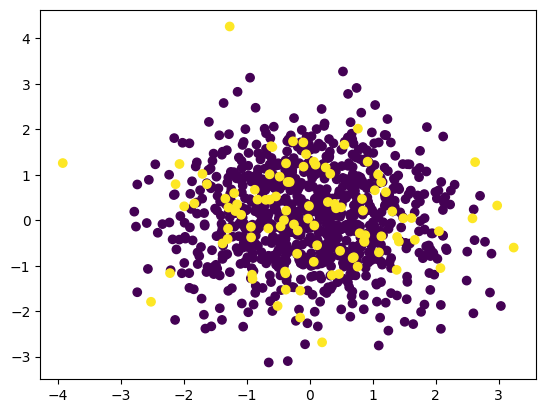

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df["feature_1"], df["feature_2"], c=df["target"])
"""
Bu kod, Matplotlib içindeki scatter fonksiyonunu kullanarak df veri setindeki
feature_1 ve feature_2 sütunlarını x ve y eksenine yerleştirir ve noktaların rengini target sütunundaki değerlere göre belirleyerek bir dağılım grafiği çizer.
"""

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversample = SMOTE()

In [ ]:
(x, y) = oversample.fit_resample(df[["feature_1", "feature_2"]], df["target"])

In [ ]:
x

,feature_1,feature_2
0,2.706850,0.536932
1,0.628133,-1.470013
2,0.907969,0.701910
3,0.503826,1.550226
4,0.651118,2.155953
...,...,...
1795,0.404736,-1.148162
1796,-0.961112,0.410648
1797,0.106520,1.234358
1798,1.731047,-0.400404


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
1795,1
1796,1
1797,1
1798,1


In [ ]:
oversample_df = pd.concat([x,y], axis=1)

In [ ]:
oversample_df

,feature_1,feature_2,target
0,2.706850,0.536932,0
1,0.628133,-1.470013,0
2,0.907969,0.701910,0
3,0.503826,1.550226,0
4,0.651118,2.155953,0
...,...,...,...
1795,0.404736,-1.148162,1
1796,-0.961112,0.410648,1
1797,0.106520,1.234358,1
1798,1.731047,-0.400404,1


In [ ]:
oversample_df["target"].value_counts()

,count
target,
0,900
1,900


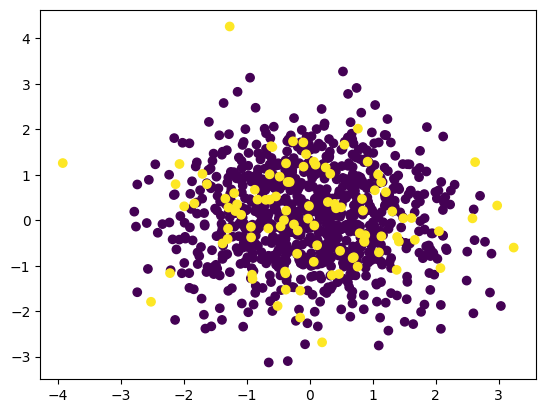

In [ ]:
plt.scatter(df["feature_1"], df["feature_2"], c=df["target"])

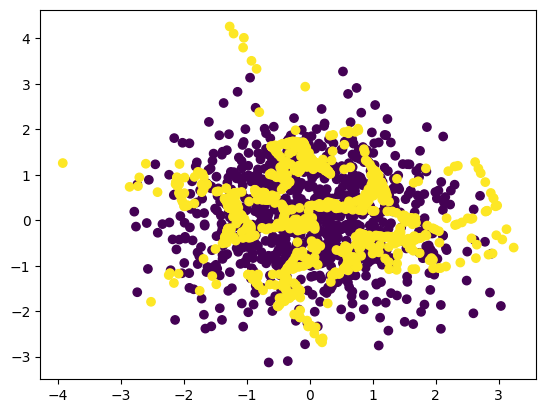

In [ ]:
plt.scatter(oversample_df["feature_1"], oversample_df["feature_2"], c=oversample_df["target"])